# IS 4487 Assignment 14: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [8]:
# Replace this list with your selected tickers
Industry = 'Technology'
tickers = ['NVDA', 'AAPL', 'MSFT', 'GOOG']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [9]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [12]:
df = yf.download(tickers, start="2019-06-01", end="2024-06-01")['High']

/tmp/ipykernel_2765/586321259.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2019-06-01", end="2024-06-01")['High']
[*********************100%***********************]  4 of 4 completed


In [13]:
df.head()

Ticker,AAPL,GOOG,MSFT,NVDA
Date,,,,
2019-06-03,42.598067,52.841179,117.028850,3.415378
2019-06-04,43.055367,52.372531,116.003171,3.557986
2019-06-05,44.290789,52.248546,118.440289,3.632023
2019-06-06,44.405704,51.948016,120.416347,3.596743
2019-06-07,45.949990,53.109967,124.443654,3.649165


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [14]:
print("Missing values before filling:")
print(df.isnull().sum())

df.fillna(method='ffill', inplace=True)

print("\nMissing values after forward fill:")
print(df.isnull().sum())

Missing values before filling:
Ticker
AAPL    0
GOOG    0
MSFT    0
NVDA    0
dtype: int64

Missing values after forward fill:
Ticker
AAPL    0
GOOG    0
MSFT    0
NVDA    0
dtype: int64


/tmp/ipykernel_2765/2852023528.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [15]:
daily_returns = df.pct_change()
daily_returns.dropna(inplace=True)
daily_returns.head()

Ticker,AAPL,GOOG,MSFT,NVDA
Date,,,,
2019-06-04,0.010735,-0.008869,-0.008764,0.041755
2019-06-05,0.028694,-0.002367,0.021009,0.020809
2019-06-06,0.002595,-0.005752,0.016684,-0.009714
2019-06-07,0.034777,0.022368,0.033445,0.014575
2019-06-10,0.017976,0.020300,0.013838,0.029344


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




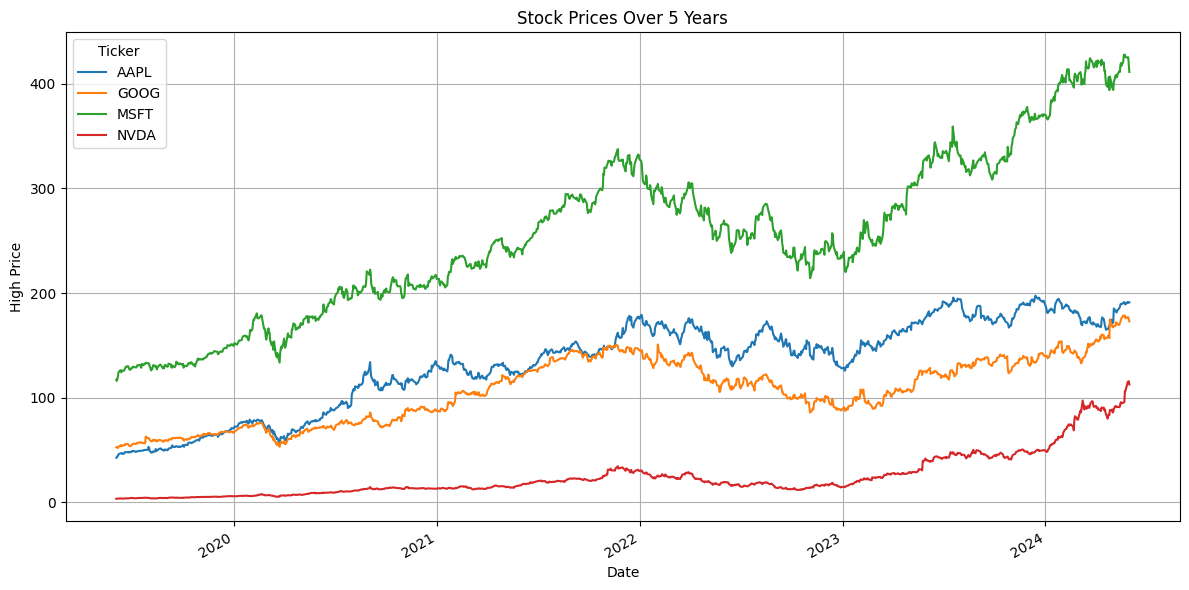


Standard Deviation of Daily Returns (Volatility):
 Ticker
AAPL    0.016996
GOOG    0.017526
MSFT    0.015113
NVDA    0.028741
dtype: float64

Correlation Matrix of Daily Returns:
 Ticker      AAPL      GOOG      MSFT      NVDA
Ticker                                        
AAPL    1.000000  0.548593  0.624887  0.523401
GOOG    0.548593  1.000000  0.616794  0.505734
MSFT    0.624887  0.616794  1.000000  0.587561
NVDA    0.523401  0.505734  0.587561  1.000000


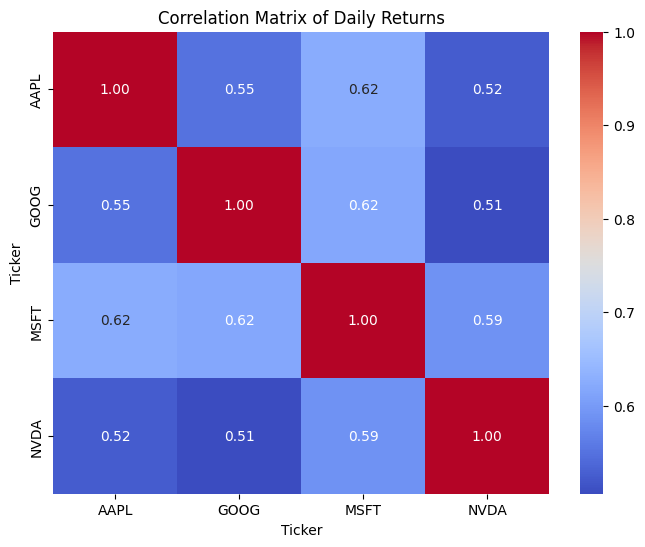

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Line chart showing stock prices over the 5-year period
plt.figure(figsize=(12, 6))
df.plot(ax=plt.gca())
plt.title('Stock Prices Over 5 Years')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.grid(True)
plt.legend(title='Ticker')
plt.tight_layout()
plt.show()

# 2. Calculate the standard deviation of daily returns for each stock (volatility)
volatility = daily_returns.std()
print("\nStandard Deviation of Daily Returns (Volatility):\n", volatility)

# 3. Create a correlation matrix of the daily returns between companies
correlation_matrix = daily_returns.corr()
print("\nCorrelation Matrix of Daily Returns:\n", correlation_matrix)

# Optional: Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Daily Returns')
plt.show()

## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Add memo here:

To: Joe Info (Investment Manager)
From: Parker Marcroft (Data Analyst)
Date: 14 April 2026
Subject: Technology Sector Performance Analysis

This analysis contains the performance and investment outlook of four technology companies, focusing on the previous five-years of Apple (AAPL), Alphabet (GOOG), Microsoft (MSFT), and NVIDIA (NVDA). We focused on assessing growth trajectory and risk profile by utilizing adjusted daily closing price. The data shows that this sector is experiencing long-term appreciation due to innovation in areas such as artificial intelligence infrastructure, chip manufacturing, and cloud computing.

A few insights can be gathered from the data in this analysis. The NVDIA stock was more volatile while Apple and Microsoft saw steady upward momentum over time. The technology sector remains fundamentally strong. The correlation matrix shows a positive correlation above 0.5 which indicates that each of these companies are experiencing many of the same market risks, suggesting that investing in all of them may impact ability to diversify.

Our recommendation from these findings is to focus on investing in the steady Microsoft and Apple investments, while being cautious with the others. In the future, we could include additional analysis such as quarterly earnings per share growth rates, sentiment analysis from financial news, and interest rate forecasting to create a prediction model. With the amount of change happening in this industry, it is necessary to update this on a monthly basis to ensure investment strategy is in sync with the market.




## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [17]:
!jupyter nbconvert --to html "assignment_14_MarcroftParker.ipynb"

[NbConvertApp] Converting notebook assignment_14_MarcroftParker.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 506497 bytes to assignment_14_MarcroftParker.html
